In [1]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 676, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 676 (delta 55), reused 58 (delta 30), pack-reused 586 (from 1)
Receiving objects: 100% (676/676), 795.36 KiB | 15.59 MiB/s, done.
Resolving deltas: 100% (333/333), done.
/content/NuOscProbExact/src
globaldefs.py  hamiltonians2nu.py  hamiltonians3nu.py  oscprob2nu.py  oscprob3nu.py


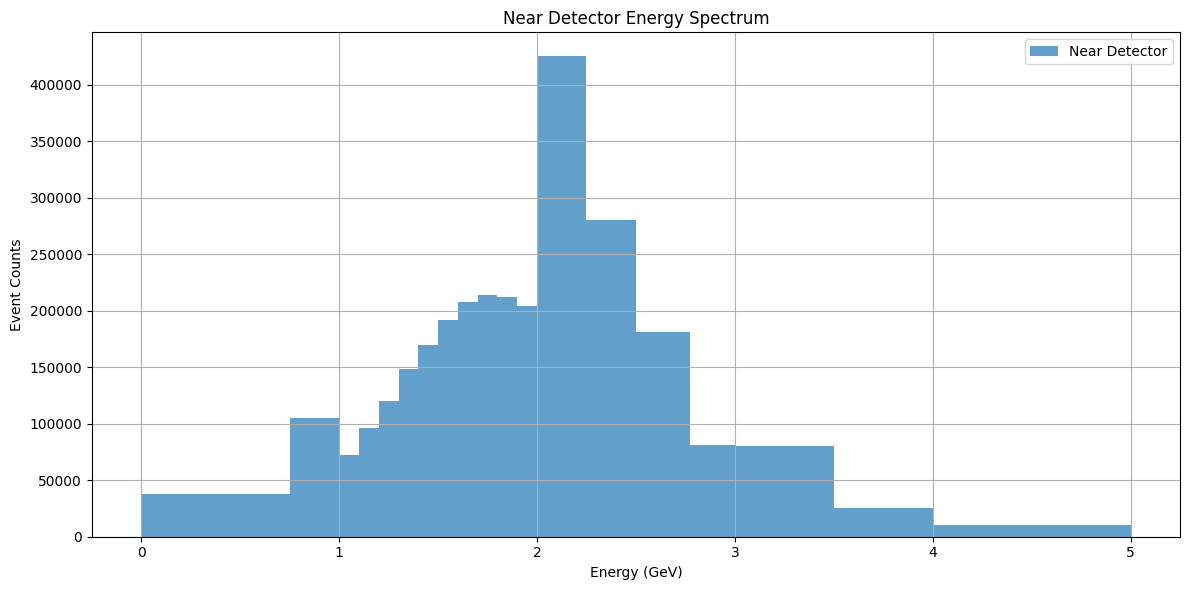

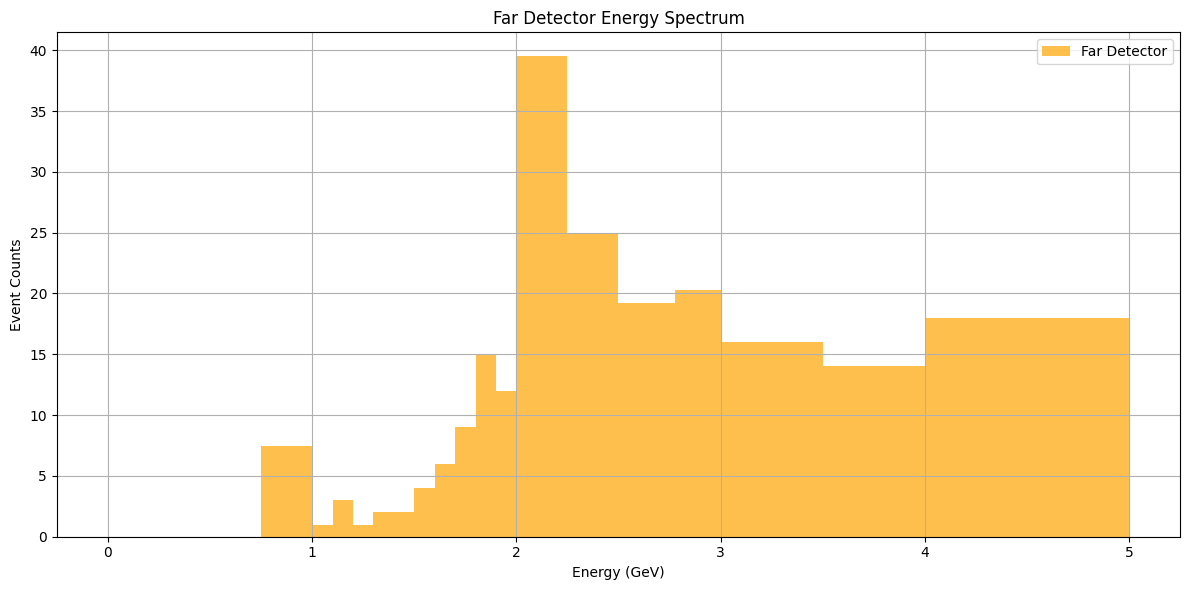

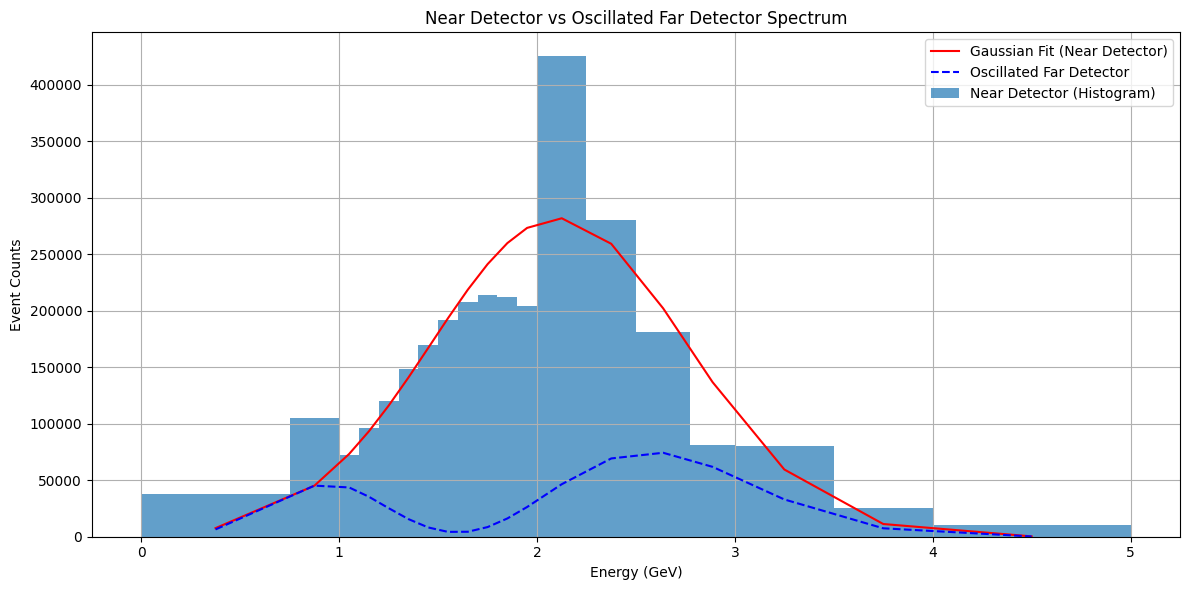

In [13]:
# Rescale bin_centers and bin_edges to GeV
bin_centers_GeV = bin_centers / 1e9  # Convert eV to GeV
bin_edges_GeV = bin_edges / 1e9      # Convert eV to GeV

# Plotting Near Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers_GeV, adjusted_counts_nd, width=np.diff(bin_edges_GeV), align='center', alpha=0.7, label='Near Detector')
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts")
plt.title("Near Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Far Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers_GeV, adjusted_counts_fd, width=np.diff(bin_edges_GeV), align='center', alpha=0.7, label='Far Detector', color='orange')
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts")
plt.title("Far Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plot Near Detector and Oscillated Far Detector Histograms
plt.figure(figsize=(12, 6))

# Near Detector
plt.bar(
    bin_centers_GeV,
    adjusted_counts_nd,
    width=np.diff(bin_edges_GeV),
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers_GeV,
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector
plt.plot(
    bin_centers_GeV,
    oscillated_fd,
    "b--",
    label="Oscillated Far Detector"
)

# Plot settings
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


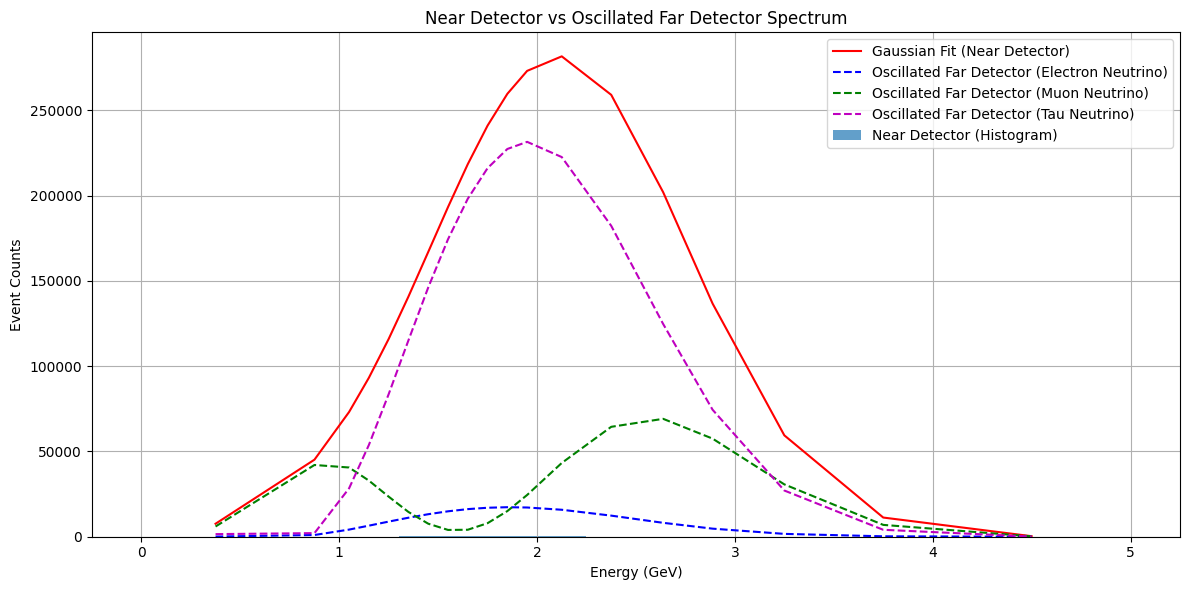

In [21]:
# Rescale bin_centers and bin_edges to GeV
bin_centers_GeV = bin_centers / 1e9  # Convert eV to GeV
bin_edges_GeV = bin_edges / 1e9      # Convert eV to GeV

# Function to compute oscillation probabilities for all three flavors
def compute_probabilities_all_flavors(baseline, energy_values):
    Prob_e, Prob_mu, Prob_tau = [], [], []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_e.append(Pme)  # Electron neutrino survival
        Prob_mu.append(Pmm)  # Muon neutrino survival
        Prob_tau.append(Pmt)  # Tau neutrino survival
    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute oscillation probabilities for all flavors at the far detector
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_all_flavors(Length_far, bin_centers)

# Generate oscillated far detector spectra for all flavors
oscillated_fd_e = gaussian(bin_centers, *popt_nd) * Prob_e_far
oscillated_fd_mu = gaussian(bin_centers, *popt_nd) * Prob_mu_far
oscillated_fd_tau = gaussian(bin_centers, *popt_nd) * Prob_tau_far

# Plot Near Detector and Oscillated Far Detector Histograms in GeV
plt.figure(figsize=(12, 6))

# Near Detector
plt.bar(
    bin_centers_GeV,  # Use bin_centers in GeV
    counts_nd,
    width=np.diff(bin_edges_GeV),  # Convert bin width from eV to GeV
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers_GeV,  # Use bin_centers in GeV
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector for all flavors
plt.plot(
    bin_centers_GeV,  # Use bin_centers in GeV
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,  # Use bin_centers in GeV
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,  # Use bin_centers in GeV
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (GeV)")  # Change the x-axis label to GeV
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



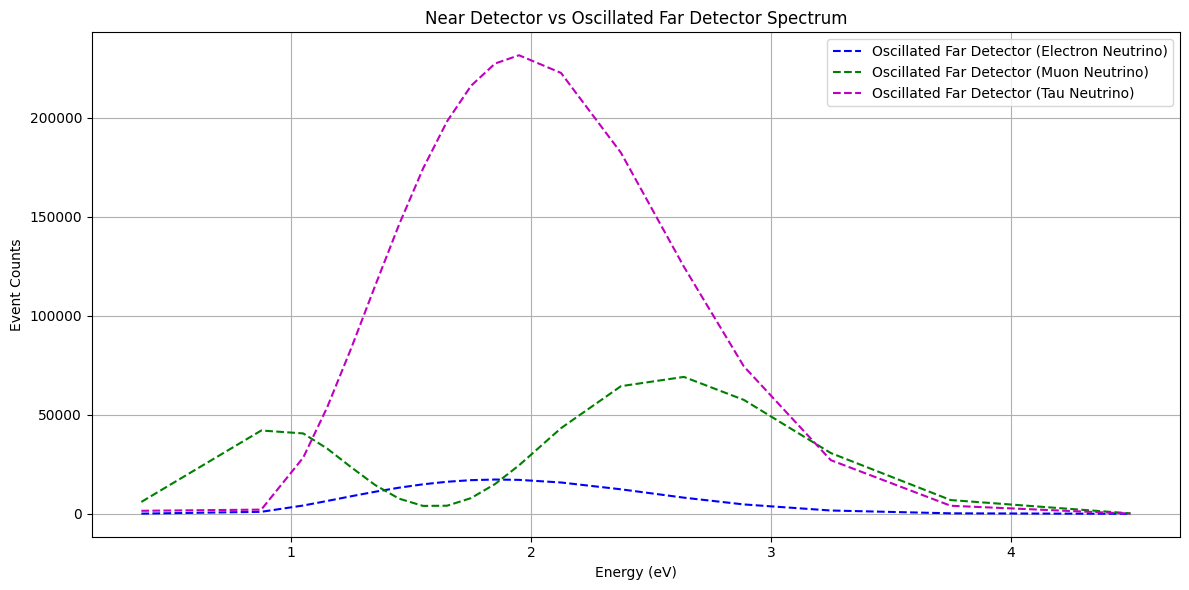

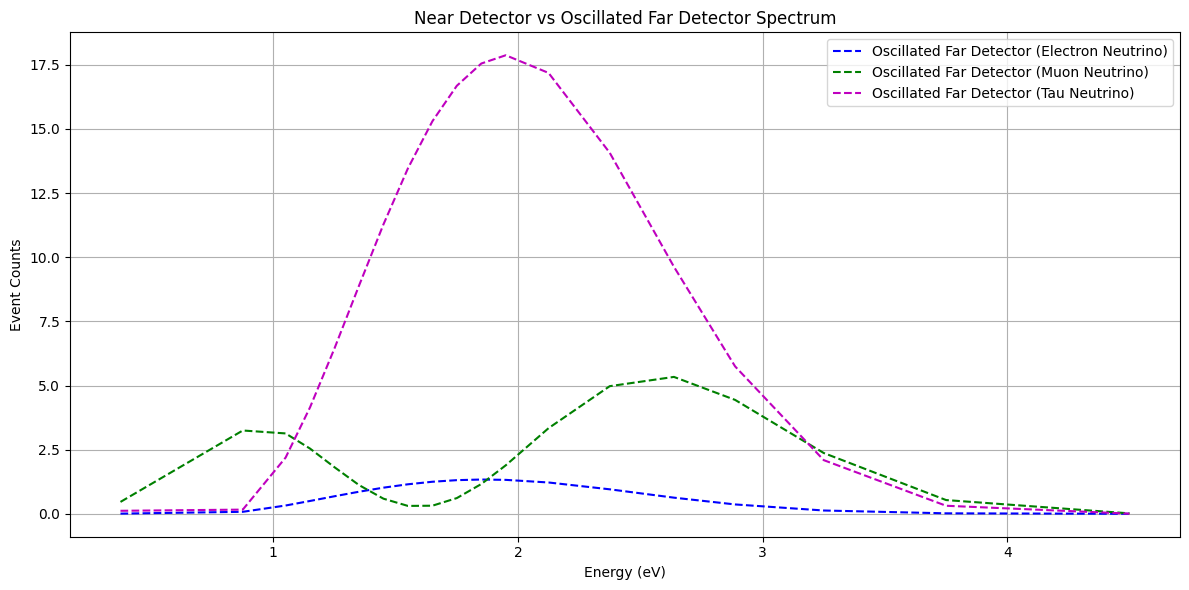

[0.01192236 0.02229554 0.05720859 0.06958791 0.07644371 0.07915168
 0.07902751 0.07709486 0.07408321 0.07048801 0.06663496 0.06273214
 0.05613913 0.04772888 0.04035475 0.03459724 0.02802556 0.02148429
 0.01513107]


In [23]:
# Function to compute oscillation probabilities for all three flavors
def compute_probabilities_all_flavors(baseline, energy_values):
    Prob_e, Prob_mu, Prob_tau = [], [], []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        # Sum contributions for each flavor
        Prob_e.append(Pme)  # Electron neutrino survival
        Prob_mu.append(Pmm)  # Muon neutrino survival
        Prob_tau.append(Pmt)  # Tau neutrino survival
    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute probabilities for all flavors at the far detector
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_all_flavors(Length_far, bin_centers)

# Generate oscillated far detector spectra for all flavors
nd_gaussian = gaussian(bin_centers, *popt_nd)  # Near detector Gaussian spectrum
oscillated_fd_e = nd_gaussian * Prob_e_far
oscillated_fd_mu = nd_gaussian * Prob_mu_far
oscillated_fd_tau = nd_gaussian * Prob_tau_far




# Plotting Near Detector and Oscillated Far Detector Spectra
plt.figure(figsize=(12, 6))



# Oscillated Far Detector
plt.plot(
    bin_centers_GeV,
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Normalize the far detector spectra to match total event counts
scale_factor_fd = np.sum(adjusted_counts_fd) / np.sum(nd_gaussian)
oscillated_fd_e *= scale_factor_fd
oscillated_fd_mu *= scale_factor_fd
oscillated_fd_tau *= scale_factor_fd



# Plotting Near Detector and Oscillated Far Detector Spectra
plt.figure(figsize=(12, 6))



# Oscillated Far Detector
plt.plot(
    bin_centers_GeV,
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)



# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(Prob_e_far)




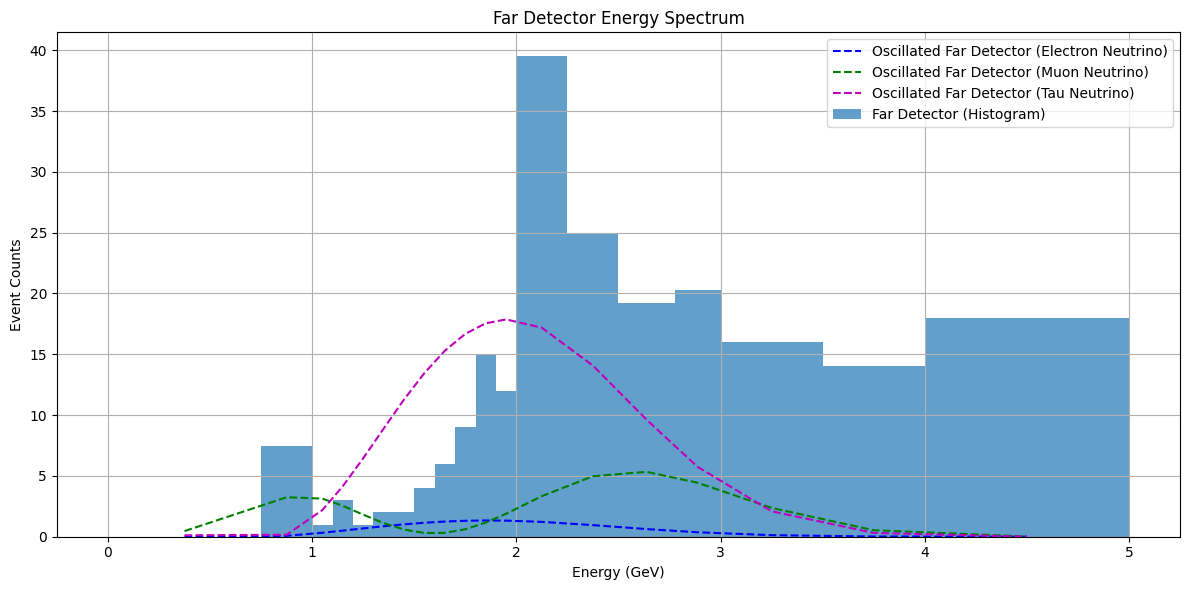

In [27]:
# Plotting Far Detector Histogram in GeV
plt.figure(figsize=(12, 6))

# Plot the histogram in GeV
plt.bar(
    bin_centers_GeV,  # bin_centers converted to GeV
    adjusted_counts_fd,
    width=np.diff(bin_edges_GeV),  # bin_edges converted to GeV
    align="center",
    alpha=0.7,
    label="Far Detector (Histogram)"  # Changed label to Far Detector
)

# Plot oscillated spectra
plt.plot(
    bin_centers_GeV,  # bin_centers converted to GeV
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,  # bin_centers converted to GeV
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,  # bin_centers converted to GeV
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (GeV)")  # Updated to GeV
plt.ylabel("Event Counts")
plt.title("Far Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


4 flavour

In [ ]:
def hamiltonian_4nu_vacuum(energy, mixing_matrix, mass_squared_differences):
    H_vacuum = np.zeros((4, 4), dtype=complex)
    for i in range(4):
        for j in range(4):
            H_vacuum[i, j] = mixing_matrix[i, j] * mixing_matrix[j, i].conj() * mass_squared_differences[i]
    H_vacuum *= 1 / (2 * energy)
    return H_vacuum


def hamiltonian_4nu_matter(h_vacuum, energy, vcc):
    V = np.zeros((4, 4), dtype=complex)
    V[0, 0] = vcc  # Only for active neutrinos (electron neutrino)
    return h_vacuum + V

def mixing_matrix_4nu(theta12, theta13, theta23, delta13, theta14, theta24, theta34, delta14, delta24):
    # Build each rotation matrix and combine
    R12 = rotation_matrix(theta12, 1, 2)
    R13 = rotation_matrix(theta13, 1, 3, delta13)
    R23 = rotation_matrix(theta23, 2, 3)
    R14 = rotation_matrix(theta14, 1, 4, delta14)
    R24 = rotation_matrix(theta24, 2, 4, delta24)
    R34 = rotation_matrix(theta34, 3, 4)
    return np.dot(R34, np.dot(R24, np.dot(R14, np.dot(R23, np.dot(R13, R12)))))

def probabilities_4nu(h_matter, baseline):
    evolution_matrix = expm(-1j * h_matter * baseline)
    probabilities = np.abs(evolution_matrix) ** 2
    return probabilities

def compute_probabilities_4nu(baseline, energy_values, mixing_matrix, mass_squared_differences, vcc):
    Prob_e, Prob_mu, Prob_tau, Prob_sterile = [], [], [], []

    for E in energy_values:
        h_vacuum = hamiltonian_4nu_vacuum(E, mixing_matrix, mass_squared_differences)
        h_matter = hamiltonian_4nu_matter(h_vacuum, E, vcc)  # Matter Hamiltonian with potential

        # Calculate oscillation probabilities
        P = probabilities_4nu(h_matter, baseline)

        # Append the survival probabilities for each flavor
        Prob_e.append(P[0, 0])  # Electron neutrino survival
        Prob_mu.append(P[1, 1])  # Muon neutrino survival
        Prob_tau.append(P[2, 2])  # Tau neutrino survival
        Prob_sterile.append(P[3, 3])  # Sterile neutrino survival

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau), np.array(Prob_sterile)


In [ ]:
# Compute probabilities for all flavors at the far detector (including sterile neutrino)
Prob_e_far, Prob_mu_far, Prob_tau_far, Prob_sterile_far = compute_probabilities_4nu(
    Length_far, bin_centers, mixing_matrix_4nu(...), mass_squared_differences, VCC_EARTH_CRUST
)

# Generate oscillated far detector spectra for all flavors (including sterile neutrino)
nd_gaussian = gaussian(bin_centers, *popt_nd)  # Near detector Gaussian spectrum
oscillated_fd_e = nd_gaussian * Prob_e_far
oscillated_fd_mu = nd_gaussian * Prob_mu_far
oscillated_fd_tau = nd_gaussian * Prob_tau_far
oscillated_fd_sterile = nd_gaussian * Prob_sterile_far  # New oscillated spectrum for sterile neutrino

# Plotting Near Detector and Oscillated Far Detector Spectra
plt.figure(figsize=(12, 6))

# Oscillated Far Detector
plt.plot(
    bin_centers,
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_sterile,
    "r--",
    label="Oscillated Far Detector (Sterile Neutrino)"  # New line for sterile neutrino
)

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (4-flavor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
